In [2]:
!python --version
!pip show tensorflow
!pip install tensorflow

Python 3.12.12
Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


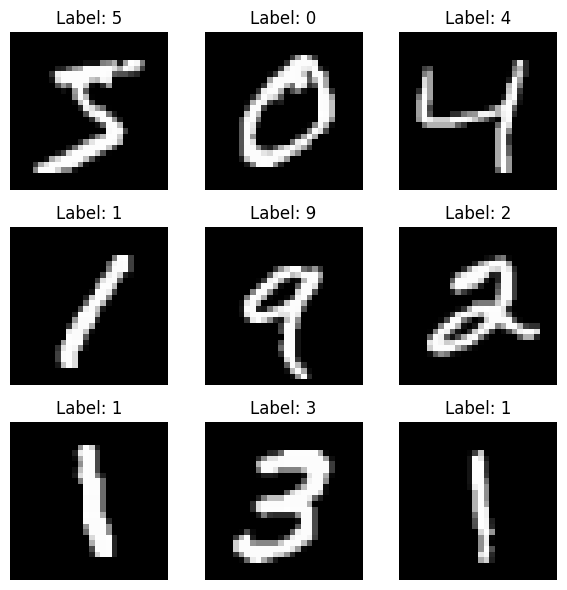

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Load the MNIST dataset
# This returns two tuples: training data and testing data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocessing
# Scale pixel values from [0, 255] to [0, 1] for better model convergence
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. Data Visualization
# Plotting the first 9 images from the training set
plt.figure(figsize=(6, 6))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
import tensorflow as tf

# 1. Define the Model Architecture
# We use 'Sequential' to stack layers on top of each other
model = tf.keras.models.Sequential([
    # Flattens the 2D (28x28) image into a 1D array of 784 pixels
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden layer with 128 neurons and ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer with 10 neurons (one for each digit 0-9)
    # Softmax turns the output into a probability distribution
    tf.keras.layers.Dense(10, activation='softmax')
])

# 2. Compile the Model
# Setting up the "rules" for how the model learns
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Optional: Print a summary of the layers
model.summary()

# 3. Train the Model
# We'll run through the dataset 5 times (epochs)
print("\nStarting training...")
model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

# 4. Save the Trained Model
# This saves the weights and the architecture so you don't have to retrain
model.save("mnist_model.h5")

print("\nModel training complete and saved as mnist_model.h5")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8763 - loss: 0.4371 - val_accuracy: 0.9615 - val_loss: 0.1296
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9642 - loss: 0.1218 - val_accuracy: 0.9715 - val_loss: 0.0930
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9763 - loss: 0.0796 - val_accuracy: 0.9750 - val_loss: 0.0823
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9833 - loss: 0.0582 - val_accuracy: 0.9761 - val_loss: 0.0759
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9865 - loss: 0.0440 - val_accuracy: 0.9751 - val_loss: 0.0785



Model training complete and saved as mnist_model.h5


In [5]:
import tensorflow as tf

# 1. Load the trained Keras model
# We load the .h5 file we created in the previous step
model = tf.keras.models.load_model("mnist_model.h5")

# 2. Initialize the TFLite Converter
# This tool analyzes the Keras graph and prepares it for optimization
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Perform the conversion
# This "freezes" the model into the flatbuffer format used by TFLite
tflite_model = converter.convert()

# 4. Save the converted model to disk
tflite_filename = "mnist_model.tflite"
with open(tflite_filename, "wb") as f:
    f.write(tflite_model)

print(f"✅ Model successfully converted and saved as {tflite_filename}")

Saved artifact at '/tmp/tmpg9mbtz26'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140133229407760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140133229399504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140133229397584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140133229407184: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model successfully converted and saved as mnist_model.tflite


In [6]:
import tensorflow as tf
import numpy as np

# 1. Load the TFLite model and allocate tensors
# "Allocating" tells the system how much memory to reserve for the math
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors()

# 2. Get Input and Output tensor details
# These tell us the required shape (e.g., [1, 28, 28]) and data type (e.g., float32)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Display the Details clearly
print("--- TFLite Model Metadata ---")
print(f"Input Shape:  {input_details[0]['shape']}")
print(f"Input Type:   {input_details[0]['dtype']}")
print(f"Output Shape: {output_details[0]['shape']}")
print(f"Output Type:  {output_details[0]['dtype']}")

# To see the full raw dictionary for debugging:
# print("\nFull Input Details:", input_details)

--- TFLite Model Metadata ---
Input Shape:  [ 1 28 28]
Input Type:   <class 'numpy.float32'>
Output Shape: [ 1 10]
Output Type:  <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


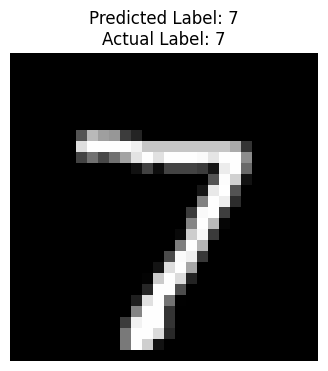

The model predicts this digit is a: 7


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the Input Image
# TFLite expects float32 and a 'batch' dimension (1, 28, 28)
test_image = x_test[0].astype(np.float32)
test_image = np.expand_dims(test_image, axis=0)

# 2. Set the Input Tensor
# We point the interpreter to our processed image
interpreter.set_tensor(input_details[0]['index'], test_image)

# 3. Run Inference
# This executes the actual mathematical calculations
interpreter.invoke()

# 4. Retrieve and Process the Prediction
# The output is a probability array (e.g., [0.1, 0.8, 0.05...])
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# 5. Visualization
plt.figure(figsize=(4, 4))
plt.imshow(x_test[0], cmap="gray")
plt.title(f"Predicted Label: {predicted_label}\nActual Label: {y_test[0]}")
plt.axis('off')
plt.show()

print(f"The model predicts this digit is a: {predicted_label}")